# Gradient Descent in Action: Multilinear Regression & Collaborative Filtering

Welcome! In this exercise you'll take gradient descent — which you just learned —
and use it to build, from scratch (using only NumPy), a working regression model.
You'll test it on synthetic data first, then generalize it and use it on a real
dataset. As a bonus, you'll reuse the exact same idea to build a tiny movie
recommender system.

**What you'll practice:**
- Turning a math formula (a linear model + a loss function) into gradient descent update rules
- Implementing gradient descent as a small, reusable Python class
- The difference between a *scalar/loop* implementation and a *vectorized* (matrix) one
- Why feature scaling matters for gradient descent
- (Bonus) How the same gradient descent idea powers recommender systems

**Rules:**
- Cells marked `# YOUR CODE HERE` are for you to fill in. Everything else is provided.
- Only use NumPy for the actual model logic (no `sklearn.linear_model`, no autograd).
  You *may* use `sklearn` for utilities like loading data, splitting, and scaling.
- Run cells in order — later cells depend on earlier ones.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
# We'll deliberately try some learning rates that are too large later on, which
# makes gradient descent blow up (huge/inf/nan numbers). That's expected and
# instructive, so we silence NumPy's overflow warnings to keep the output clean.
np.seterr(over="ignore", invalid="ignore")

## 1. Multilinear Regression — the 2-feature case

In simple linear regression you fit a line $\hat{y} = wx + b$ through 1D data.
**Multilinear regression** just means the model has *more than one* input feature,
combined linearly. With two features $x_1, x_2$:

$$\hat{y} = w_1 x_1 + w_2 x_2 + b$$

Geometrically, instead of fitting a *line* through 2D points, you're fitting a
**plane** through 3D points $(x_1, x_2, y)$.

As before, we measure how wrong the model is with the **mean squared error**:

$$L(w_1, w_2, b) = \frac{1}{n}\sum_{i=1}^{n} \left(\hat{y}_i - y_i\right)^2, \qquad \hat{y}_i = w_1 x_{1,i} + w_2 x_{2,i} + b$$

and we improve $w_1, w_2, b$ with **gradient descent**: repeatedly step each
parameter a little bit in the direction that decreases $L$ the fastest —

$$
w_1 \leftarrow w_1 - \eta \frac{\partial L}{\partial w_1}, \qquad
w_2 \leftarrow w_2 - \eta \frac{\partial L}{\partial w_2}, \qquad
b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$

where $\eta$ (`lr`) is the learning rate. You already derived gradients like
these in class — try working out $\frac{\partial L}{\partial w_1}$,
$\frac{\partial L}{\partial w_2}$, and $\frac{\partial L}{\partial b}$
yourself before looking. (It's the same chain-rule pattern as simple linear
regression, just with one more term.)

<details>
<summary>Derivatives (click to reveal)</summary>

$$
\frac{\partial L}{\partial w_1} = \frac{2}{n}\sum_i (\hat{y}_i - y_i)\, x_{1,i}
\qquad
\frac{\partial L}{\partial w_2} = \frac{2}{n}\sum_i (\hat{y}_i - y_i)\, x_{2,i}
\qquad
\frac{\partial L}{\partial b} = \frac{2}{n}\sum_i (\hat{y}_i - y_i)
$$

</details>

## 2. Exercise 1 — Implement `MultilinearRegression2D`

Implement the class below. `__init__` is done for you. You need to fill in:

- **`predict(x1, x2)`** — returns $\hat{y} = w_1 x_1 + w_2 x_2 + b$ for arrays `x1`, `x2`.
- **`fit(x1, x2, y)`** — runs gradient descent for `self.n_iters` steps. On every
  step: compute predictions, compute the MSE loss (append it to `self.loss_history`
  so we can plot it later), compute the three gradients, and update `w1`, `w2`, `b`.

`x1`, `x2`, `y` will always be 1D NumPy arrays of the same length `n`.

In [3]:
class MultilinearRegression2D:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.w1 = 0.0
        self.w2 = 0.0
        self.b = 0.0
        self.loss_history = []   # MSE loss at each iteration, for plotting

    def predict(self, x1, x2):
        return self.w1*x1 + self.w2*x2 + self.b

    def fit(self, x1, x2, y):
        """Run gradient descent for self.n_iters steps to fit w1, w2, b to the data."""
        for _ in range(self.n_iters):
            # 1. compute predictions
            y_hat = self.predict(x1, x2)


            # 2. compute the MSE loss and append it to self.loss_history
            error = np.mean((y_hat - y)**2)
            self.loss_history.append(error)


            # 3. compute the gradients dw1, dw2, db
            dw1 = 2*np.mean((y_hat - y)*x1)
            dw2 = 2*np.mean((y_hat - y)*x2)
            db = 2*np.mean((y_hat - y))
            

            # 4. update self.w1, self.w2, self.b using the gradients and self.lr
            self.w1 -= self.lr*dw1
            self.w2 -= self.lr*dw2
            self.b -= self.lr*db

## 3. Try it out: synthetic data

We'll generate data from a plane we choose ourselves — `true_w1 = 3`,
`true_w2 = -2`, `true_b = 5` — plus a bit of random noise. Since we *know* the
true parameters, this is the best way to sanity-check that your implementation
is actually correct: if it works, gradient descent should recover values close
to the true ones.

In [5]:
import numpy as np
n = 200
x1 = np.random.uniform(-5, 5, n)
x2 = np.random.uniform(-5, 5, n)

true_w1, true_w2, true_b = 3.0, -2.0, 5.0
noise = np.random.normal(0, 0.5, n)
y = true_w1 * x1 + true_w2 * x2 + true_b + noise

In [8]:
# Create a MultilinearRegression2D, fit it on (x1, x2, y), and store it in `model`.
model = MultilinearRegression2D(lr=0.001, n_iters=100_000)
model.fit(x1, x2, y)

print(f"learned: w1={model.w1:.3f}, w2={model.w2:.3f}, b={model.b:.3f}")
print(f"true:    w1={true_w1},      w2={true_w2},      b={true_b}")

learned: w1=2.972, w2=-1.991, b=5.031
true:    w1=3.0,      w2=-2.0,      b=5.0


Now let's visualize two things: how the loss dropped during training (it should
decrease and flatten out), and the fitted plane against the actual data points.

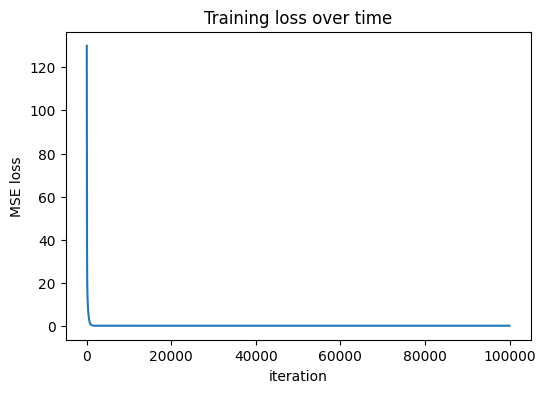

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(model.loss_history)
ax.set_xlabel("iteration")
ax.set_ylabel("MSE loss")
ax.set_title("Training loss over time")
plt.show()

The plot below uses [Plotly](https://plotly.com/python/) instead of
Matplotlib so you can **drag to rotate it and scroll to zoom** — much easier
to judge how well a plane fits a 3D point cloud than from one fixed angle. If
Plotly isn't installed (`pip install plotly`), it automatically falls back to
a static Matplotlib plot.

In [12]:
try:
    import plotly.graph_objects as go

    x1_grid, x2_grid = np.meshgrid(
        np.linspace(x1.min(), x1.max(), 20),
        np.linspace(x2.min(), x2.max(), 20),
    )
    y_grid = model.predict(x1_grid, x2_grid)

    fig = go.Figure(data=[
        go.Scatter3d(
            x=x1, y=x2, z=y, mode="markers",
            marker=dict(size=3, opacity=0.6, color="steelblue"),
            name="data",
        ),
        go.Surface(
            x=x1_grid, y=x2_grid, z=y_grid, opacity=0.5,
            colorscale=[[0, "orange"], [1, "orange"]], showscale=False,
            name="fitted plane",
        ),
    ])
    fig.update_layout(
        title="Fitted plane vs. data — drag to rotate, scroll to zoom",
        scene=dict(xaxis_title="x1", yaxis_title="x2", zaxis_title="y"),
        width=750, height=600,
        margin=dict(l=0, r=0, b=0, t=40),
    )
    fig.show()

except ImportError:
    print("Plotly isn't installed (pip install plotly for an interactive, "
          "rotatable version) -- showing a static Matplotlib plot instead.")

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(x1, x2, y, alpha=0.6, label="data")

    x1_grid, x2_grid = np.meshgrid(
        np.linspace(x1.min(), x1.max(), 10),
        np.linspace(x2.min(), x2.max(), 10),
    )
    y_grid = model.predict(x1_grid, x2_grid)
    ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.3, color="orange")

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("y")
    ax.set_title("Fitted plane vs. data")
    plt.show()

### Play with the learning rate

The learning rate $\eta$ (`lr`) controls how big each gradient descent step
is. Fit several `MultilinearRegression2D` models on the *same* `(x1, x2, y)`
data below, changing only `lr`, and plot their loss curves together.

Try something very small (e.g. `1e-4`), something "reasonable" (like the
`0.01` you used above), and something clearly too large — try a few values
until you find one where training visibly blows up rather than converges.

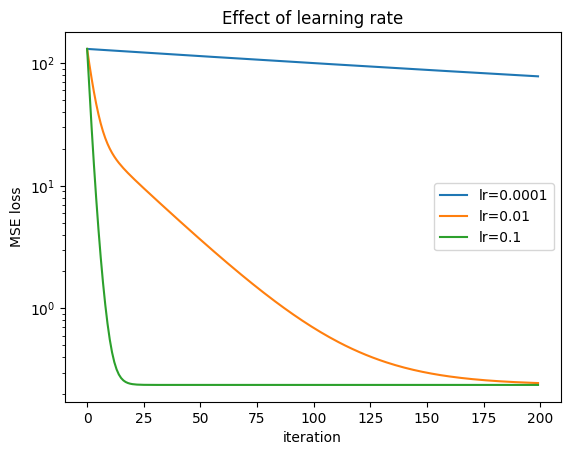

In [21]:
lrs_to_try = [1e-4, 1e-2, 0.1]   # replace the last value with one that's too large
n_iters_lr = 200

plt.figure()
for lr in lrs_to_try:
    # Create+fit a MultilinearRegression2D with this lr and n_iters=n_iters_lr,
    # then plot its loss_history with a label showing the lr value.
    model = MultilinearRegression2D(lr, n_iters_lr)
    model.fit(x1, x2, y)
    plt.plot(model.loss_history, label=f"lr={lr}")

    

plt.xlabel("iteration"); plt.ylabel("MSE loss"); plt.yscale("log")
plt.legend(); plt.title("Effect of learning rate")
plt.show()

**Your observations:** *(double-click this cell to edit, and write 2-3
sentences)*

- What happened with the very small learning rate — after 200 iterations, had
  it finished converging, or was it still on its way?
- What happened with the too-large one? What does that tell you about what
  "the gradient" is actually doing to the weights each step?
- If you had to pick one learning rate to use for the rest of this notebook,
  how would you go about choosing it?

*(your answer here)*

## 4. Bonus: Polynomial Regression — Fitting a Curve with a Linear Model

So far you've only fit data that's roughly planar. But look at the data
generated below — a single input `x` plotted against `y`. It's clearly
**not** a straight line or plane.

**The challenge:** without changing a single line of your
`MultilinearRegression2D` class, can you still use it to fit this curve?
Think about it before expanding the hint below — what could you use as `x1`
and `x2`? (They don't have to be two different measured quantities — they
just have to be two numbers you can compute from `x`.)

<details>
<summary>Hint (click to expand)</summary>

Your model computes $\hat{y} = w_1 x_1 + w_2 x_2 + b$. Nothing requires $x_1$
and $x_2$ to be two *independently measured* features — what if $x_1 = x$ and
$x_2 = x^2$? Then $\hat{y} = w_1 x + w_2 x^2 + b$, a **quadratic function of
$x$** — even though it's still *linear in the weights* $w_1, w_2, b$, which is
all gradient descent actually cares about. This trick is called **polynomial
regression**: a "linear model" can fit non-linear data, as long as you feed it
non-linear *features*.

</details>

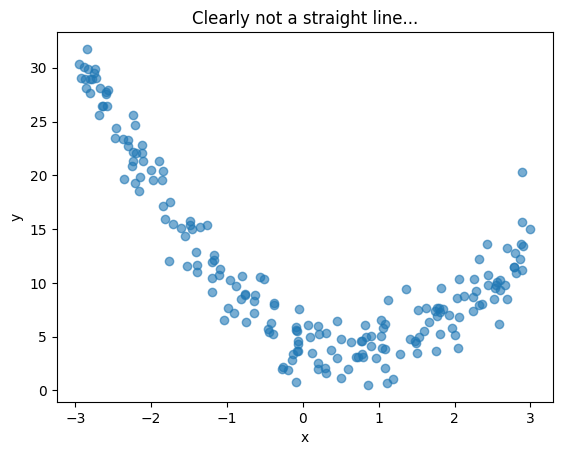

In [1]:
import numpy as np
import matplotlib.pyplot as plt
n_poly = 200
x_poly = np.random.uniform(-3, 3, n_poly)
true_a, true_bq, true_cq = 2.0, -3.0, 5.0   # y = a*x^2 + b*x + c
y_poly = true_a * x_poly**2 + true_bq * x_poly + true_cq + np.random.normal(0, 2.0, n_poly)

plt.figure()
plt.scatter(x_poly, y_poly, alpha=0.6)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Clearly not a straight line...")
plt.show()

In [4]:
# Build two features from x_poly so that your existing MultilinearRegression2D
# can fit this curve, then fit it. Store the model in `poly_model`.
# YOUR CODE HERE
x1_poly = x_poly
x2_poly = x_poly**2
poly_model = MultilinearRegression2D(0.001, 10_000)
poly_model.fit(x1_poly, x2_poly, y_poly)

print(f"learned: w1={poly_model.w1:.3f}, w2={poly_model.w2:.3f}, b={poly_model.b:.3f}")
print(f"true:    b={true_bq} (~w1), a={true_a} (~w2), c={true_cq} (~b)")

learned: w1=-2.976, w2=2.061, b=4.839
true:    b=-3.0 (~w1), a=2.0 (~w2), c=5.0 (~b)


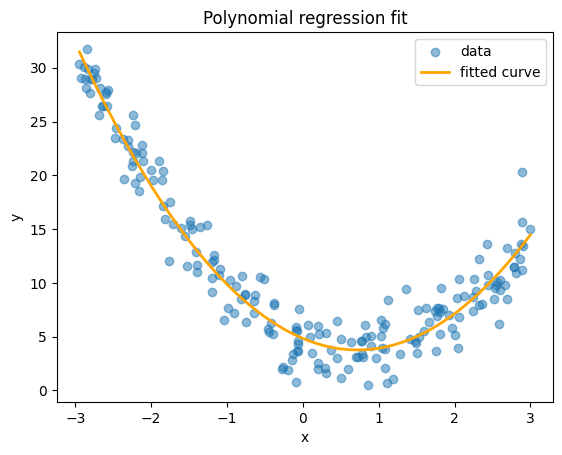

In [5]:
x_sorted = np.sort(x_poly)
y_curve = poly_model.predict(x_sorted, x_sorted ** 2)

plt.figure()
plt.scatter(x_poly, y_poly, alpha=0.5, label="data")
plt.plot(x_sorted, y_curve, color="orange", linewidth=2, label="fitted curve")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Polynomial regression fit")
plt.show()

Notice that `MultilinearRegression2D` itself never changed — it still just
fits $\hat{y} = w_1 x_1 + w_2 x_2 + b$. All the "non-linearity" came from how
you *engineered* $x_1$ and $x_2$ before handing them to the model. This idea —
that a linear model can fit non-linear relationships as long as it stays
linear in its *parameters* — will come back in the next section: any of the
$d$ features you feed the general model could themselves be polynomial terms,
interaction terms, or any other function of your raw measurements you can
compute in advance.

## 5. General Multilinear Regression

Real data rarely has just 2 features. The idea generalizes directly: with $d$
features, stack the weights into a vector $w = (w_1, \dots, w_d)$ and write each
example's features as a vector $x_i = (x_{i,1}, \dots, x_{i,d})$:

$$\hat{y}_i = w^T x_i + b = \sum_{j=1}^d w_j x_{i,j} + b$$

Stacking all $n$ examples into a matrix $X \in \mathbb{R}^{n\times d}$ (one row per
example) lets us compute *every* prediction at once, with no loop:

$$\hat{y} = Xw + b$$

The loss is the same MSE as before, and the gradients generalize the same way —
now $\frac{\partial L}{\partial w}$ is a whole vector (one entry per feature).
Try to figure out its shape and formula yourself first — it should collapse to
exactly your two `w1`/`w2` gradients above when $d=2$.

<details>
<summary>Gradients (click to reveal)</summary>

$$L(w, b) = \frac{1}{n}\lVert \hat{y} - y \rVert^2 \qquad
\frac{\partial L}{\partial w} = \frac{2}{n} X^\top (\hat{y} - y) \qquad
\frac{\partial L}{\partial b} = \frac{2}{n}\sum_i (\hat{y}_i - y_i)$$

</details>

This is exactly the same gradient descent loop as before — we've just replaced
scalars with vectors/matrices, which NumPy handles for us with `@` (matrix
multiply) instead of writing loops over features by hand.

## 6. Exercise 2 — Implement `MultilinearRegression` (general, vectorized)

Same structure as before, but now `X` is a 2D array of shape `(n_samples,
n_features)`, `self.w` is a 1D array of shape `(n_features,)`, and everything
should be **vectorized** (no Python loop over features or examples — only the
loop over iterations).

In [ ]:
class MultilinearRegression:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None      # will become a (n_features,) array in fit()
        self.b = 0.0
        self.loss_history = []

    def predict(self, X):
        """X has shape (n_samples, n_features). Return shape (n_samples,)."""
        # YOUR CODE HERE
        pass

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        for _ in range(self.n_iters):
            # 1. predictions
            # YOUR CODE HERE

            # 2. MSE loss -> self.loss_history
            # YOUR CODE HERE

            # 3. gradients dw (shape (n_features,)) and db (scalar)
            # YOUR CODE HERE

            # 4. update self.w and self.b
            # YOUR CODE HERE
            pass

### Sanity check on synthetic multi-dimensional data

Same idea as before: generate data from weights we choose, and check that
`MultilinearRegression` recovers them.

In [ ]:
n, d = 300, 5
X_syn = np.random.uniform(-3, 3, (n, d))
true_w = np.array([1.5, -2.0, 0.5, 3.0, -1.0])
true_b_syn = 2.0
y_syn = X_syn @ true_w + true_b_syn + np.random.normal(0, 0.3, n)

In [ ]:
# Create a MultilinearRegression, fit it on (X_syn, y_syn), store it in `model_syn`.
# YOUR CODE HERE
model_syn = None

print("learned w:", np.round(model_syn.w, 3))
print("true w:   ", true_w)
print(f"learned b: {model_syn.b:.3f}, true b: {true_b_syn}")

plt.figure()
plt.plot(model_syn.loss_history)
plt.xlabel("iteration"); plt.ylabel("MSE loss"); plt.title("Training loss")
plt.show()

*(Optional)* Try the same learning-rate experiment as in section 3 here too —
does the same "too small / just right / too large" pattern still hold once
there are 5 features instead of 2?

## 7. Real data: California Housing

Now let's use `MultilinearRegression` on a real dataset: the **California
Housing** dataset (one row per census block group in California; features like
median income, house age, average rooms, population, latitude/longitude; target
is the median house value).

In [ ]:
from sklearn.model_selection import train_test_split

try:
    from sklearn.datasets import fetch_california_housing
    housing = fetch_california_housing()
    X_real, y_real, feature_names = housing.data, housing.target, housing.feature_names
    dataset_name = "California Housing"
except Exception as e:
    # Falls back to a dataset that ships with scikit-learn (no download needed)
    # in case internet access is unavailable, e.g. on a restricted school network.
    # Note: this fallback's features are pre-normalized by sklearn, so it won't
    # show the scaling effect below as dramatically as California Housing does.
    print(f"Could not download California Housing ({e}); falling back to the "
          f"built-in Diabetes dataset.")
    from sklearn.datasets import load_diabetes
    diabetes = load_diabetes()
    X_real, y_real, feature_names = diabetes.data, diabetes.target, diabetes.feature_names
    dataset_name = "Diabetes"

print(f"Using: {dataset_name}")
print("features:", list(feature_names))
print("X shape:", X_real.shape, " y shape:", y_real.shape)
for j, name in enumerate(feature_names):
    print(f"  {name:>12}:  min={X_real[:, j].min():.2f}  max={X_real[:, j].max():.2f}")

X_train, X_test, y_train, y_test = train_test_split(X_real, y_real, test_size=0.2, random_state=42)

### First attempt: fit directly on the raw data

Look at the per-feature min/max printed above — the features are on very
different scales. Let's ignore that for now and just try fitting
`MultilinearRegression` directly on `X_train`/`y_train` as-is, the same way
you did on the synthetic data.

Experiment with `lr_unscaled` below: start around `0.1` and, if training
doesn't behave (loss exploding, or ending up `nan`/`inf`), divide it by 10 and
try again. Keep going until you find a value that trains *stably* — then
check how good the resulting loss actually is, and how many iterations it
took to get there.

In [ ]:
lr_unscaled = 0.1   # <- try different values, see the guidance above

unscaled_model = MultilinearRegression(lr=lr_unscaled, n_iters=2000)
unscaled_model.fit(X_train, y_train)

plt.figure()
plt.plot(unscaled_model.loss_history)
plt.xlabel("iteration"); plt.ylabel("MSE loss")
plt.title(f"Training loss, unscaled data, lr={lr_unscaled}")
plt.show()

print("final loss:", unscaled_model.loss_history[-1])
print("final w:", unscaled_model.w)

**Your observations (unscaled):** *(double-click this cell to edit)*

- What was the smallest number of "divide by 10" steps that got you a stable
  (non-exploding) loss curve?
- Even once it's stable, is training fast? Does the loss get as low as it did
  on the synthetic data?
- Any guess as to *why* this dataset is so much more sensitive to `lr` than
  the synthetic one was?

*(your answer here)*

### Fixing it: feature scaling

Gradient descent takes **one** learning rate for *all* weights at once, so if
features have wildly different scales, a learning rate that's sensible for one
feature (say, latitude, which ranges over a few tens) can be far too large for
another (population, which ranges into the tens of thousands) — that mismatch
is exactly what made `lr` so fiddly to tune above.

The fix is to **standardize** each feature: subtract its mean and divide by its
standard deviation, so every feature has mean 0 and standard deviation 1. That
way every feature's gradient is on a comparable scale, and a single `lr` can
work well for all of them at once.

Implement standardization yourself below (don't use `sklearn.preprocessing`),
being careful to compute the mean/std **only from the training set** and reuse
those same numbers on the test set (the model should never "see" test data
during fitting, including implicitly through preprocessing statistics).

In [ ]:
def standardize(X_train, X_test):
    """
    Compute mean/std from X_train (per feature), and use them to standardize
    both X_train and X_test. Return (X_train_scaled, X_test_scaled).
    """
    # YOUR CODE HERE
    pass

X_train_s, X_test_s = standardize(X_train, X_test)
print("train mean (should be ~0):", X_train_s.mean(axis=0).round(3))
print("train std  (should be ~1):", X_train_s.std(axis=0).round(3))

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Create a MultilinearRegression, fit it on the SCALED training data,
# predict on the scaled test data, and store the predictions in `y_pred`.
# Try lr=0.1 to start with (the same value that likely misbehaved on raw
# data above) — compare how it behaves now.
# YOUR CODE HERE
real_model = None
y_pred = None

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test MSE: {mse:.3f}")
print(f"Test R^2: {r2:.3f}")

plt.figure()
plt.plot(real_model.loss_history)
plt.xlabel("iteration"); plt.ylabel("MSE loss"); plt.title(f"Training loss ({dataset_name})")
plt.show()

**Your observations (scaled vs. unscaled):** *(double-click this cell to
edit)*

- Did `lr=0.1` "just work" this time, without any divide-by-10 hunting?
- Compare the final loss and R² here to your unscaled attempt — which model
  actually fit the data better, given the same (or fewer) iterations?
- In your own words: what did standardizing the features actually change
  about the optimization problem, that made picking `lr` so much easier?

*(your answer here)*

## 8. Bonus — Collaborative Filtering

**Goal:** given a big table of movie ratings (most of it missing — no one has
rated every movie), predict the missing ratings, so we can recommend movies a
user hasn't seen yet but would probably like. This is the same idea behind
"Because you watched..." on streaming services.

**The model.** Give every user $u$ a vector $p_u \in \mathbb{R}^k$ and every
item (movie) $i$ a vector $q_i \in \mathbb{R}^k$ ("latent factors" — you can
think of them as $k$ learned, unlabeled taste dimensions). Predict the rating
user $u$ would give item $i$ as a dot product:

$$\hat{r}_{u,i} = p_u^T q_i$$

**The loss.** Same MSE idea, but summed only over the ratings we actually
observed (there's no "true" value for missing ratings to compare against!),
plus a regularization term that discourages $p_u, q_i$ from growing huge
(which helps avoid overfitting on users/items with very few ratings):

$$L(P, Q) = \frac{1}{|\mathcal{R}|}\sum_{(u,i) \in \mathcal{R}} \left(p_u^T q_i - r_{u,i}\right)^2
\;+\; \lambda \left(\sum_u \lVert p_u \rVert^2 + \sum_i \lVert q_i \rVert^2\right)$$

where $\mathcal{R}$ is the set of (user, item) pairs with an observed rating,
and $\lambda$ (`reg`) is the regularization strength.

**The gradients.** This is *still* gradient descent — we're just descending on
two matrices, $P$ (all users' vectors stacked, shape `(n_users, k)`) and $Q$
(all items' vectors stacked, shape `(n_items, k)`), instead of one weight
vector. Let $M$ be the **mask** matrix (`M[u,i] = 1` if we have a rating for
`(u,i)`, else `0`), and $E = M \odot (PQ^\top - R)$ be the masked error (using
$\odot$ for elementwise multiply — this makes sure unobserved entries
contribute exactly 0 to the gradient):

$$\frac{\partial L}{\partial P} = \frac{2}{|\mathcal{R}|} E Q + 2\lambda P
\qquad\qquad
\frac{\partial L}{\partial Q} = \frac{2}{|\mathcal{R}|} E^\top P + 2\lambda Q$$

Update $P \leftarrow P - \eta \frac{\partial L}{\partial P}$ and
$Q \leftarrow Q - \eta \frac{\partial L}{\partial Q}$, same as always.

### Loading the data: MovieLens 100K

The cell below downloads the classic [MovieLens 100K](https://grouplens.org/datasets/movielens/100k/)
dataset (100,000 ratings from 943 users on 1,682 movies) and builds the ratings
matrix `R` and mask matrix `mask`, split into train/test *by rating* (not by
user — we still want to predict for users we've partially seen). This part is
provided since it's file-parsing, not gradient descent.

If your network blocks the download, grab `ml-100k.zip` manually from the link
above, unzip it next to this notebook, and re-run the cell. (If you instead
see a certificate error, the cell below already works around it — see the
comment inside.)

In [ ]:
import os
import ssl
import urllib.error
import urllib.request
import zipfile

DATA_DIR = "ml-100k"
if not os.path.exists(DATA_DIR):
    url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
    print("Downloading MovieLens 100K...")
    try:
        urllib.request.urlretrieve(url, "ml-100k.zip")
    except urllib.error.URLError as e:
        if "CERTIFICATE_VERIFY_FAILED" not in str(e):
            raise
        # GroupLens's server certificate has, from time to time, been left to
        # expire even though the dataset file itself is fine. This is a
        # narrow, one-off workaround: skip certificate verification for this
        # SINGLE well-known, static, non-sensitive academic dataset. This is
        # NOT something to do out of habit for arbitrary URLs — you'd be
        # throwing away the guarantee that you're really talking to the
        # server you think you are.
        print("Certificate check failed (a known GroupLens server-side issue) "
              "— retrying without verification...")
        ctx = ssl._create_unverified_context()
        with urllib.request.urlopen(url, context=ctx) as resp, open("ml-100k.zip", "wb") as f:
            f.write(resp.read())
    with zipfile.ZipFile("ml-100k.zip", "r") as z:
        z.extractall(".")
    print("Done.")

ratings = np.loadtxt(os.path.join(DATA_DIR, "u.data"), dtype=int)  # columns: user, item, rating, timestamp
n_users = ratings[:, 0].max()
n_items = ratings[:, 1].max()
print(f"{len(ratings)} ratings, {n_users} users, {n_items} items")

movie_titles = {}
with open(os.path.join(DATA_DIR, "u.item"), encoding="latin-1") as f:
    for line in f:
        parts = line.split("|")
        movie_titles[int(parts[0])] = parts[1]

rng = np.random.default_rng(0)
shuffled = rng.permutation(len(ratings))
n_test = int(0.2 * len(ratings))
test_idx, train_idx = shuffled[:n_test], shuffled[n_test:]

def build_matrices(idx):
    R = np.zeros((n_users, n_items))
    mask = np.zeros((n_users, n_items))
    u = ratings[idx, 0] - 1
    i = ratings[idx, 1] - 1
    r = ratings[idx, 2]
    R[u, i] = r
    mask[u, i] = 1
    return R, mask

R_train, mask_train = build_matrices(train_idx)
R_test, mask_test = build_matrices(test_idx)

### Exercise 3 — Implement `CollaborativeFiltering`

Fill in `fit` and `predict`. `P` and `Q` are initialized to small random values
for you (starting them at exactly 0 would keep every gradient at 0 forever —
think about why, from the formulas above).

In [ ]:
class CollaborativeFiltering:
    def __init__(self, n_factors=10, lr=10.0, reg=0.0002, n_iters=300, seed=0):
        self.n_factors = n_factors
        self.lr = lr
        self.reg = reg
        self.n_iters = n_iters
        self.seed = seed
        self.loss_history = []

    def fit(self, R, mask):
        """R, mask both have shape (n_users, n_items). R's entries are only
        meaningful where mask == 1."""
        rng = np.random.default_rng(self.seed)
        n_users, n_items = R.shape
        self.P = 0.1 * rng.standard_normal((n_users, self.n_factors))
        self.Q = 0.1 * rng.standard_normal((n_items, self.n_factors))
        n_ratings = mask.sum()

        for _ in range(self.n_iters):
            # 1. predicted ratings matrix: self.P @ self.Q.T
            # YOUR CODE HERE

            # 2. masked error E = mask * (pred - R)
            # YOUR CODE HERE

            # 3. loss: mean squared error over observed entries + regularization
            #    -> append to self.loss_history
            # YOUR CODE HERE

            # 4. gradients dP, dQ (see formulas above)
            # YOUR CODE HERE

            # 5. update self.P, self.Q
            # YOUR CODE HERE
            pass

    def predict(self):
        """Return the full predicted ratings matrix, shape (n_users, n_items)."""
        # YOUR CODE HERE
        pass

### Train it and check the results

We evaluate with **RMSE** (root mean squared error — same units as the
ratings, 1-5 stars, so it's easier to interpret than raw MSE) on the held-out
test ratings the model never trained on.

In [ ]:
cf = CollaborativeFiltering(n_factors=10, lr=10.0, reg=0.0002, n_iters=300)
cf.fit(R_train, mask_train)
pred = cf.predict()

train_rmse = np.sqrt(np.sum(mask_train * (pred - R_train) ** 2) / mask_train.sum())
test_rmse = np.sqrt(np.sum(mask_test * (pred - R_test) ** 2) / mask_test.sum())
print(f"train RMSE: {train_rmse:.3f}")
print(f"test RMSE:  {test_rmse:.3f}")

plt.figure()
plt.plot(cf.loss_history)
plt.xlabel("iteration"); plt.ylabel("loss"); plt.title("Collaborative filtering training loss")
plt.show()

If `test RMSE` isn't much worse than `train RMSE` and both look reasonable
(roughly 0.9-1.0 stars of error is typical for a first, untuned model on this
dataset), it's working. If the loss curve explodes to `nan`, your learning rate
is too high — try lowering it. If the loss barely moves, either raise the
learning rate or run more iterations.

Now let's use the trained model to recommend movies: for one user, find the
movies they *haven't* rated yet, sorted by predicted rating.

In [ ]:
def recommend(user_id, n=10):
    u = user_id - 1
    already_rated = (mask_train[u] + mask_test[u]) > 0
    scores = pred[u].copy()
    scores[already_rated] = -np.inf   # never recommend something already rated
    top_items = np.argsort(scores)[::-1][:n]
    return [(movie_titles[i + 1], scores[i]) for i in top_items]

for title, score in recommend(user_id=1, n=10):
    print(f"{score:.2f}  {title}")

## Wrap-up

You implemented gradient descent three times — for a 2-feature model, for a
general $d$-feature model, and for matrix factorization — and every time it
was the *exact same four steps*: predict, compute loss, compute gradients,
update parameters. That pattern is the core of how nearly all of deep learning
is trained, just with much bigger models.

**If you want to go further, try:**
- Extend the polynomial regression trick from section 4: add $x^3$ (or higher
  powers) as another feature, using your general `MultilinearRegression` class
  this time since a cubic fit needs 3 weights, not 2. Does it fit better, or
  does it start overfitting the noise?
- Plot predicted vs. actual values for the California Housing model — where
  does the model do well or poorly?